In [114]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

data1 = np.loadtxt('1.txt')
data2 = np.loadtxt('2.txt')
n1 = len(data1)
n2 = len(data2)
time1 = np.arange(n1)
time2 = np.arange(n2)
print(f"Ряд 1 (синусоидальный): {n1} значений, mu={np.mean(data1):.3f}, sigma={np.std(data1):.3f}")
print(f"Ряд 2 (линейный): {n2} значений, mu={np.mean(data2):.3f}, sigma={np.std(data2):.3f}")


Ряд 1 (синусоидальный): 64 значений, mu=0.229, sigma=2.468
Ряд 2 (линейный): 64 значений, mu=14.634, sigma=7.852


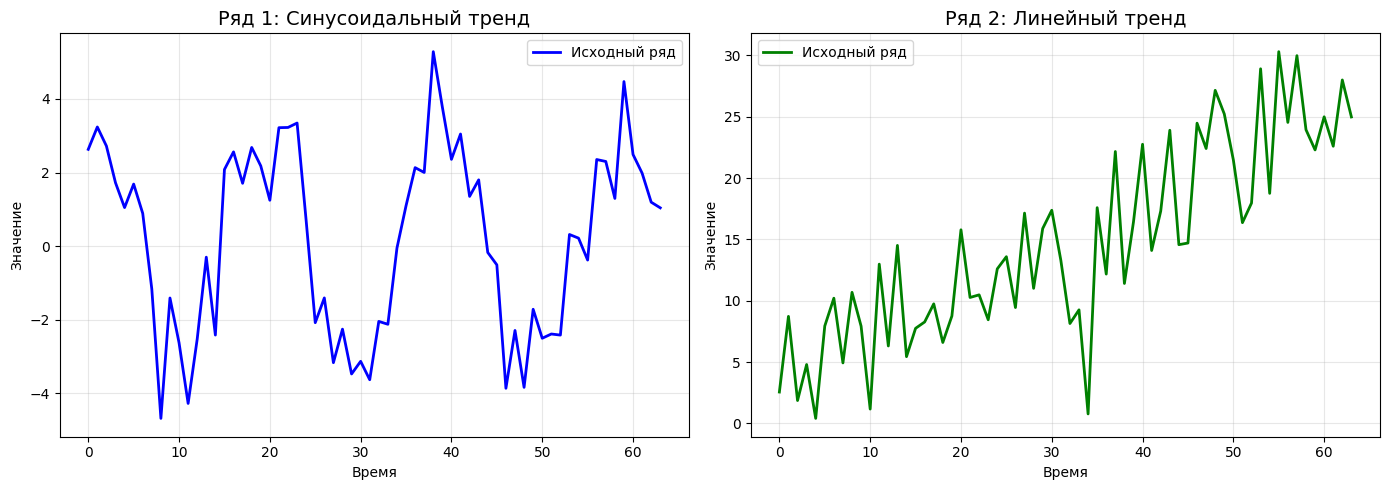

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(time1, data1, 'b-', linewidth=2, label='Исходный ряд')
axes[0].set_title('Ряд 1: Синусоидальный тренд', fontsize=14)
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Значение')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(time2, data2, 'g-', linewidth=2, label='Исходный ряд')
axes[1].set_title('Ряд 2: Линейный тренд', fontsize=14)
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Значение')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## Функции сглаживания

In [116]:
def sma(data, m):
    w = 2 * m + 1
    weights = np.ones(w) / w
    padded_data = np.pad(data, (m, m), mode='edge')
    smoothed = np.convolve(padded_data, weights, mode='valid')
    return smoothed

def wma(data, m, eps=0.3):
    w = 2 * m + 1
    i_vals = np.arange(-m, m + 1)
    weights = np.exp(-eps * np.abs(i_vals))
    weights /= weights.sum()
    padded_data = np.pad(data, (m, m), mode='edge')
    smoothed = np.convolve(padded_data, weights, mode='valid')
    return smoothed

def ema(data, alpha):
    n = len(data)
    smoothed = np.zeros(n)
    smoothed[0] = data[0]
    for i in range(1, n):
        smoothed[i] = alpha * data[i] + (1 - alpha) * smoothed[i - 1]
    return smoothed

def dema(data, alpha, gamma):
    n = len(data)
    smoothed = np.zeros(n)
    b = np.zeros(n)
    smoothed[0] = data[0]
    b[0] = data[1] - data[0] if n > 1 else 0
    for i in range(1, n):
        smoothed[i] = alpha * data[i] + (1 - alpha) * (smoothed[i - 1] + b[i - 1])
        b[i] = gamma * (smoothed[i] - smoothed[i - 1]) + (1 - gamma) * b[i - 1]
    return smoothed

## Функции анализа

In [117]:
def calculate_residuals(original, smoothed):
    if len(original) != len(smoothed):
        offset = (len(original) - len(smoothed)) // 2
        residuals = original[offset:-offset] - smoothed
    else:
        residuals = original - smoothed
    return residuals

def q_test(residuals, lag=5):
    result = acorr_ljungbox(residuals, lags=[lag], return_df=True)
    q_stat = result['lb_stat'].iloc[0]
    p_value = result['lb_pvalue'].iloc[0]
    return q_stat, p_value

def durbin_watson_test(residuals):
    dw = durbin_watson(residuals)
    dL, dU = 1.57, 1.63
    if dw <= 2:
        d = dw
    else:
        d = 4 - dw
    if d < dL:
        interpretation = "Положительная автокорреляция"
    elif d > dU:
        interpretation = "Нет автокорреляции"
    else:
        interpretation = "Неопределенность"
    return d, interpretation

In [118]:
def find_best_parameters(data, method_name, lag=5):
    best_params = None
    best_q = float('inf')
    best_smoothed = None
    best_residuals = None
    if method_name == 'SMA' or method_name == 'WMA':
        m_values = [3, 5, 7, 9]
        for m in m_values:
            if method_name == 'SMA':
                smoothed = sma(data, m)
            else:
                smoothed = wma(data, m)
            residuals = calculate_residuals(data, smoothed)
            q_stat, _ = q_test(residuals, lag)
            if q_stat < best_q:
                best_q = q_stat
                best_params = {'m': m}
                best_smoothed = smoothed
                best_residuals = residuals
    elif method_name == 'EMA':
        alpha_values = np.arange(0.1, 1.0, 0.1)
        for alpha in alpha_values:
            smoothed = ema(data, alpha)
            residuals = calculate_residuals(data, smoothed)
            q_stat, _ = q_test(residuals, lag)
            if q_stat < best_q:
                best_q = q_stat
                best_params = {'alpha': alpha}
                best_smoothed = smoothed
                best_residuals = residuals
    elif method_name == 'DEMA':
        alpha_values = np.arange(0.1, 1.0, 0.1)
        gamma_values = np.arange(0.1, 1.0, 0.1)
        for alpha in alpha_values:
            for gamma in gamma_values:
                smoothed = dema(data, alpha, gamma)
                residuals = calculate_residuals(data, smoothed)
                q_stat, _ = q_test(residuals, lag)
                if q_stat < best_q:
                    best_q = q_stat
                    best_params = {'alpha': alpha, 'gamma': gamma}
                    best_smoothed = smoothed
                    best_residuals = residuals
    return best_params, best_q, best_smoothed, best_residuals

In [119]:
def process_all_methods(data, data_name, lag=5):
    results = {}
    methods = ['SMA', 'WMA', 'EMA', 'DEMA']
    for method in methods:
        print(f"\n{method} - {data_name}")
        params, q_stat, smoothed, residuals = find_best_parameters(data, method, lag)
        dw_stat, dw_interp = durbin_watson_test(residuals)
        results[method] = {
            'params': params,
            'q_stat': q_stat,
            'smoothed': smoothed,
            'residuals': residuals,
            'dw_stat': dw_stat,
            'dw_interp': dw_interp
        }
        print(f"  Оптимальные параметры: {params}")
        print(f"  Q-статистика: {q_stat:.4f}")
        print(f"  Тест Дарбина-Уотсона: {dw_stat:.4f} ({dw_interp})")
    return results

In [120]:
def plot_smoothing_results(data, results, data_name):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    methods = ['SMA', 'WMA', 'EMA', 'DEMA']
    for idx, method in enumerate(methods):
        ax = axes[idx]
        result = results[method]
        if method in ['SMA', 'WMA']:
            offset = (len(data) - len(result['smoothed'])) // 2
            time_adj = np.arange(offset, len(data) - offset)
            ax.plot(time_adj, result['smoothed'], 'r-', linewidth=2, label=f'{method} сглаженный')
            ax.plot(np.arange(len(data)), data, 'b-', alpha=0.5, label='Исходный')
        else:
            ax.plot(np.arange(len(data)), result['smoothed'], 'r-', linewidth=2, label=f'{method} сглаженный')
            ax.plot(np.arange(len(data)), data, 'b-', alpha=0.5, label='Исходный')
        params_str = ', '.join([f'{k}={v:.2f}' for k, v in result['params'].items()])
        ax.set_title(f'{method} - {data_name}\n{params_str}\nQ={result["q_stat"]:.2f}, DW={result["dw_stat"]:.3f}')
        ax.set_xlabel('Время')
        ax.set_ylabel('Значение')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle(f'Сглаживание ряда: {data_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

АНАЛИЗ РЯДА 1 (СИНУСОИДАЛЬНЫЙ ТРЕНД)

SMA - Ряд 1 (синусоидальный)
  Оптимальные параметры: {'m': 3}
  Q-статистика: 1.9555
  Тест Дарбина-Уотсона: 1.9610 (Нет автокорреляции)

WMA - Ряд 1 (синусоидальный)
  Оптимальные параметры: {'m': 3}
  Q-статистика: 3.8114
  Тест Дарбина-Уотсона: 1.7066 (Нет автокорреляции)

EMA - Ряд 1 (синусоидальный)
  Оптимальные параметры: {'alpha': np.float64(0.8)}
  Q-статистика: 6.6194
  Тест Дарбина-Уотсона: 1.9439 (Нет автокорреляции)

DEMA - Ряд 1 (синусоидальный)
  Оптимальные параметры: {'alpha': np.float64(0.5), 'gamma': np.float64(0.7000000000000001)}
  Q-статистика: 1.6673
  Тест Дарбина-Уотсона: 1.9351 (Нет автокорреляции)

АНАЛИЗ РЯДА 2 (ЛИНЕЙНЫЙ ТРЕНД)

SMA - Ряд 2 (линейный)
  Оптимальные параметры: {'m': 9}
  Q-статистика: 6.9739
  Тест Дарбина-Уотсона: 1.6224 (Неопределенность)

WMA - Ряд 2 (линейный)
  Оптимальные параметры: {'m': 9}
  Q-статистика: 10.3295
  Тест Дарбина-Уотсона: 1.3970 (Положительная автокорреляция)

EMA - Ряд 2 (линейный

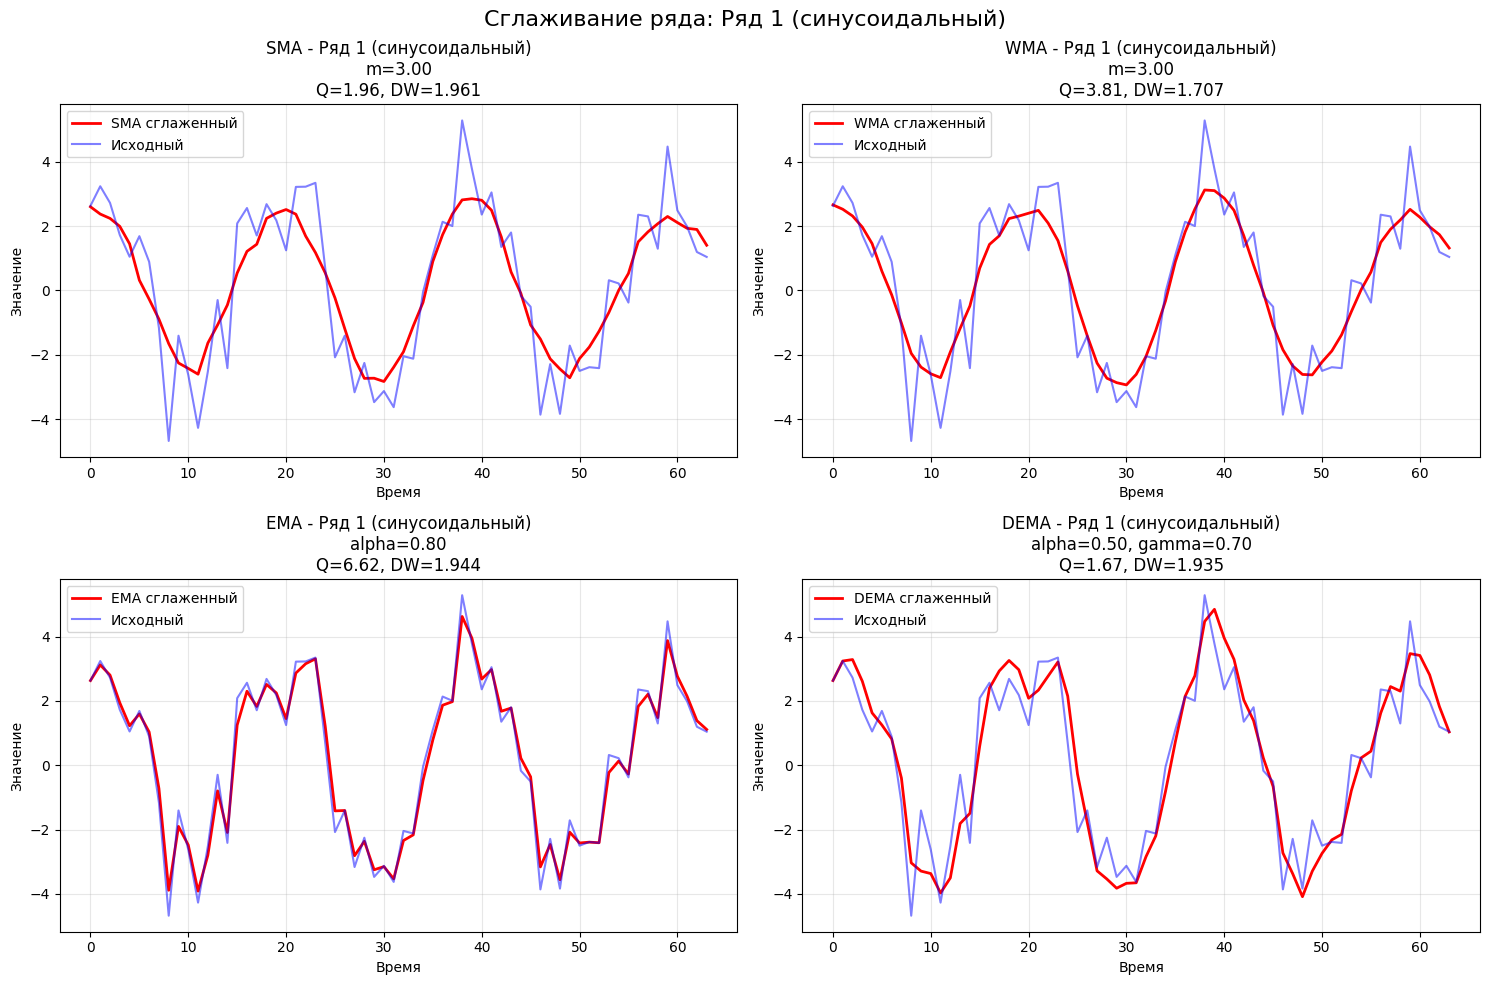

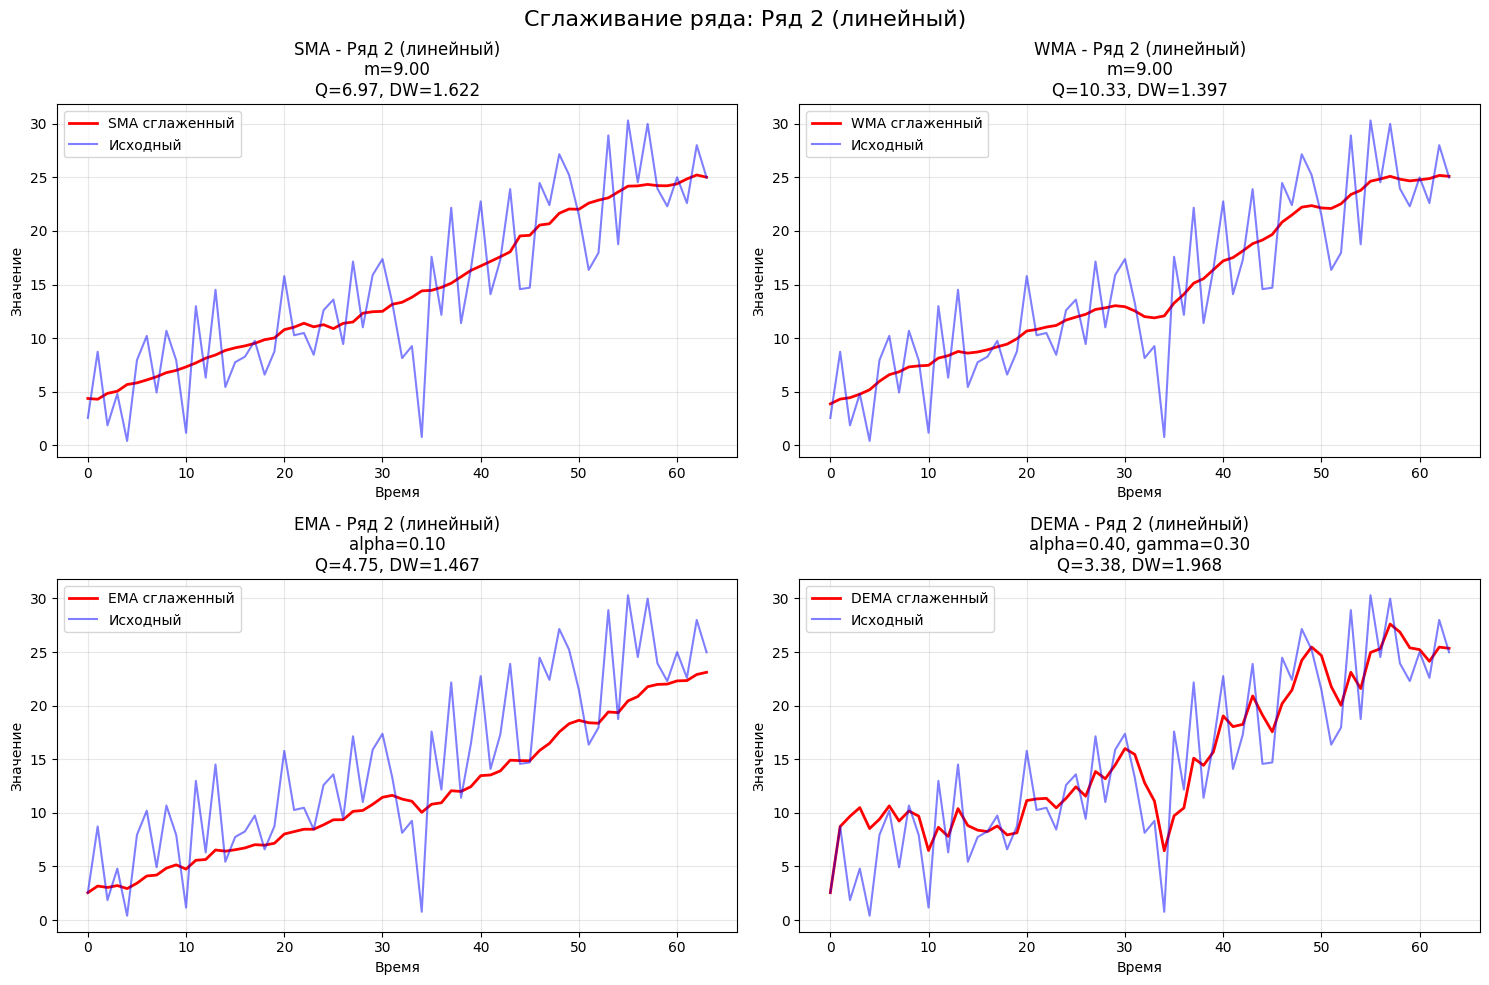

In [122]:
print("АНАЛИЗ РЯДА 1 (СИНУСОИДАЛЬНЫЙ ТРЕНД)")
results1 = process_all_methods(data1, "Ряд 1 (синусоидальный)")
print("\nАНАЛИЗ РЯДА 2 (ЛИНЕЙНЫЙ ТРЕНД)")
results2 = process_all_methods(data2, "Ряд 2 (линейный)")
plot_smoothing_results(data1, results1, "Ряд 1 (синусоидальный)")
plot_smoothing_results(data2, results2, "Ряд 2 (линейный)")